In [2]:
!pip install opencv-python

import cv2 as cv
import numpy as np
# Thay 'TenSV' bằng tên thật của bạn viết liền không dấu nhé!
import matplotlib.pyplot as Tai

# Đọc ảnh theo đúng cú pháp yêu cầu
img = cv.imread('hinh1.jpg')

# Chuyển đổi màu để hiển thị đúng trên matplotlib và tạo bản grayscale
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

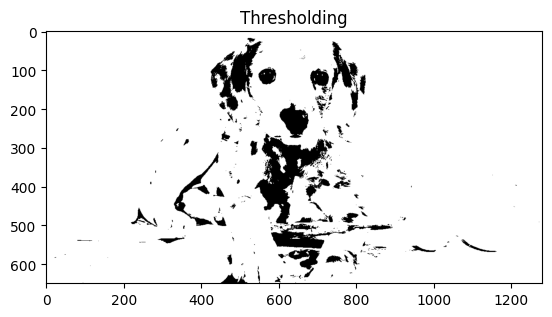

In [3]:
# Phân đoạn ảnh bằng Global Thresholding
ret, thresh_img = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)
Tai.imshow(thresh_img, cmap='gray')
Tai.title("Thresholding")
Tai.show()

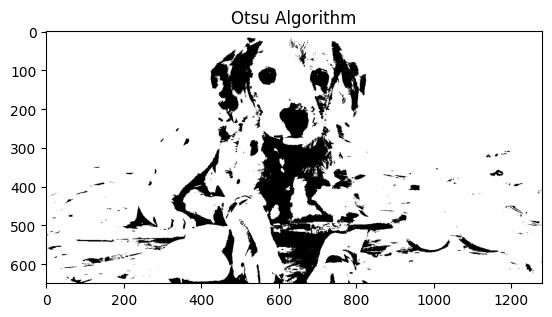

In [4]:
ret_otsu, otsu_img = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
Tai.imshow(otsu_img, cmap='gray')
Tai.title("Otsu Algorithm")
Tai.show()

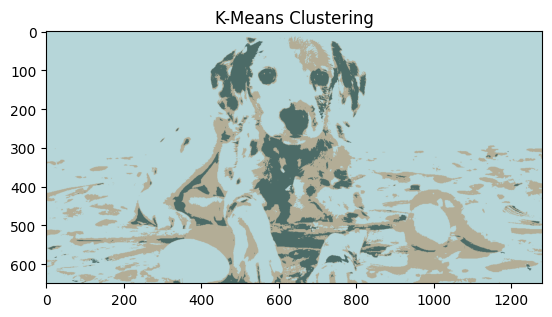

In [5]:
# Chuyển đổi định dạng dữ liệu cho K-Means
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Thiết lập tiêu chí dừng và số lượng cụm (K)
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3 # Bạn có thể thay đổi số lượng cụm
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Chuyển đổi lại hình ảnh
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
kmeans_img = segmented_data.reshape(img_rgb.shape)

Tai.imshow(kmeans_img)
Tai.title("K-Means Clustering")
Tai.show()

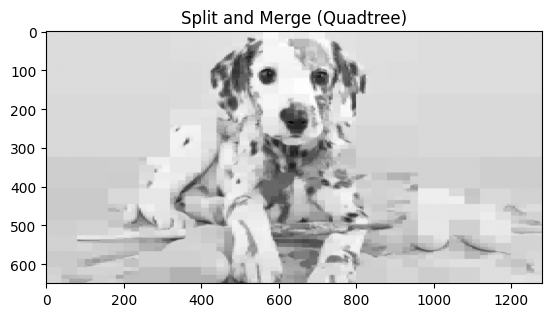

In [6]:
img = cv.imread('hinh1.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

def split_and_merge(img_region, threshold_std):
    # Điều kiện dừng: nếu kích thước vùng quá nhỏ (vd <= 4x4)
    if img_region.shape[0] <= 4 or img_region.shape[1] <= 4:
        return np.full(img_region.shape, np.mean(img_region), dtype=np.uint8)

    # Tính độ lệch chuẩn để kiểm tra mức độ đồng nhất
    std_dev = np.std(img_region)

    if std_dev < threshold_std:
        # Vùng đồng nhất -> Merge: gán giá trị trung bình cho toàn vùng
        return np.full(img_region.shape, np.mean(img_region), dtype=np.uint8)
    else:
        # Vùng không đồng nhất -> Split: chia làm 4 phần
        h, w = img_region.shape
        h2, w2 = h // 2, w // 2

        top_left = split_and_merge(img_region[:h2, :w2], threshold_std)
        top_right = split_and_merge(img_region[:h2, w2:], threshold_std)
        bottom_left = split_and_merge(img_region[h2:, :w2], threshold_std)
        bottom_right = split_and_merge(img_region[h2:, w2:], threshold_std)

        # Nối 4 phần lại với nhau
        top = np.hstack((top_left, top_right))
        bottom = np.hstack((bottom_left, bottom_right))
        return np.vstack((top, bottom))

# Áp dụng hàm với ngưỡng độ lệch chuẩn (ví dụ: 15)
# Ngưỡng càng nhỏ, ảnh bị chia càng chi tiết
result_img = split_and_merge(img_gray, 15)

Tai.imshow(result_img, cmap='gray')
Tai.title("Split and Merge (Quadtree)")
Tai.show()

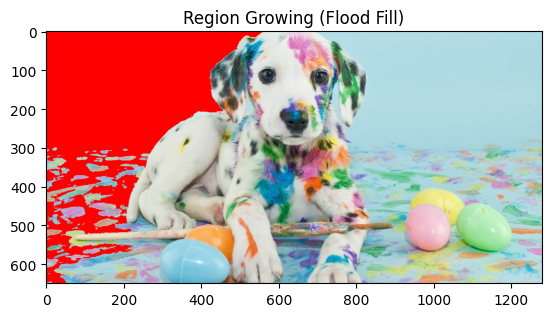

In [9]:

# Tạo mask bắt buộc cho floodFill (kích thước phải lớn hơn ảnh gốc 2 pixels)
h, w = img.shape[:2]
mask = np.zeros((h+2, w+2), np.uint8)

# 1. Chọn điểm hạt giống (seed point) - ví dụ tọa độ (x=100, y=100)
seed_point = (100, 100)

# 2. Giá trị màu mới để tô cho vùng được phân đoạn (ví dụ màu đỏ)
new_color = (255, 0, 0)

# 3. Khoảng dung sai màu sắc (Lower và Upper chênh lệch so với pixel gốc)
lo_diff = (20, 20, 20)
up_diff = (20, 20, 20)

# Thực hiện Region Growing bằng Flood Fill
cv.floodFill(img_rgb, mask, seed_point, new_color, lo_diff, up_diff, cv.FLOODFILL_FIXED_RANGE)

# Hiển thị kết quả
Tai.imshow(img_rgb)
Tai.title("Region Growing (Flood Fill)")
Tai.show()

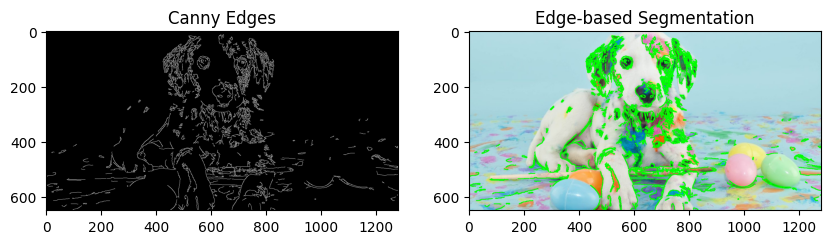

In [11]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 1. Phát hiện cạnh bằng thuật toán Canny
# Tham số 100 và 200 là ngưỡng MinVal và MaxVal
edges = cv.Canny(img_gray, 100, 200)

# 2. Tìm các đường viền (contours) từ ảnh cạnh thu được
contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# 3. Vẽ các đường viền lên ảnh gốc để tạo phân đoạn hiển thị rõ ràng
segmented_img = img_rgb.copy()
# Tham số -1 nghĩa là vẽ tất cả contours, (0, 255, 0) là màu xanh lá, 2 là độ dày nét vẽ
cv.drawContours(segmented_img, contours, -1, (0, 255, 0), 2)

# Hiển thị kết quả cạnh và kết quả phân đoạn
fig, ax = Tai.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(edges, cmap='gray')
ax[0].set_title('Canny Edges')
ax[1].imshow(segmented_img)
ax[1].set_title('Edge-based Segmentation')
Tai.show()